In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
# find the number of missing values in each column but i wanna see only those columns which have missing values
missing_count = df.isnull().sum()
missing_values = missing_count[missing_count > 0]

#display the result in a sorted manner where 

missing_values , missing_values.sort_values(ascending=False)



(LotFrontage      259
 Alley           1369
 MasVnrType       872
 MasVnrArea         8
 BsmtQual          37
 BsmtCond          37
 BsmtExposure      38
 BsmtFinType1      37
 BsmtFinType2      38
 Electrical         1
 FireplaceQu      690
 GarageType        81
 GarageYrBlt       81
 GarageFinish      81
 GarageQual        81
 GarageCond        81
 PoolQC          1453
 Fence           1179
 MiscFeature     1406
 dtype: int64,
 PoolQC          1453
 MiscFeature     1406
 Alley           1369
 Fence           1179
 MasVnrType       872
 FireplaceQu      690
 LotFrontage      259
 GarageType        81
 GarageYrBlt       81
 GarageFinish      81
 GarageQual        81
 GarageCond        81
 BsmtFinType2      38
 BsmtExposure      38
 BsmtFinType1      37
 BsmtCond          37
 BsmtQual          37
 MasVnrArea         8
 Electrical         1
 dtype: int64)

In [4]:
#display the percentage of the missing values in each column where value is greater than 0
df.isnull().mean().sort_values(ascending=False) * 100 


PoolQC         99.520548
MiscFeature    96.301370
Alley          93.767123
Fence          80.753425
MasVnrType     59.726027
                 ...    
ExterQual       0.000000
Exterior2nd     0.000000
Exterior1st     0.000000
RoofMatl        0.000000
SalePrice       0.000000
Length: 81, dtype: float64

In [5]:
def missing_info(df):
    # Calculate the total number of missing values in each column
    missing_count = df.isnull().sum()

    # Calculate the percentage of missing values in each column
    missing_percentage = df.isnull().mean() * 100

    # Create a new DataFrame with column name, missing count and percentage
    missing_df = pd.DataFrame({
        "column_name": df.columns,
        "missing_values_count": missing_count,
        "missing_value_percentage": missing_percentage
    })

    # Keep only the columns that contain missing values
    missing_df = missing_df[missing_df["missing_values_count"] > 0]

    # Sort the DataFrame in descending order based on missing value percentage
    missing_df.sort_values(
        by="missing_value_percentage",
        ascending=False,
        inplace=True
    )

    # Reset the index for better readability
    missing_df.reset_index(drop=True, inplace=True)

    # Return the final DataFrame
    return missing_df

# Display the missing value summary
missing_df = missing_info(df)
missing_df

,column_name,missing_values_count,missing_value_percentage
0,PoolQC,1453,99.520548
1,MiscFeature,1406,96.301370
2,Alley,1369,93.767123
3,Fence,1179,80.753425
4,MasVnrType,872,59.726027
5,FireplaceQu,690,47.260274
6,LotFrontage,259,17.739726
7,GarageType,81,5.547945
8,GarageYrBlt,81,5.547945
9,GarageFinish,81,5.547945


In [6]:
# columns with missing values
ns = df.isnull().sum()
mask = ns >0
ns = ns[mask].sort_values(ascending=False)
missing_cols = ns.index
missing_cols

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
       'LotFrontage', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageQual', 'GarageCond', 'BsmtFinType2', 'BsmtExposure',
       'BsmtFinType1', 'BsmtCond', 'BsmtQual', 'MasVnrArea', 'Electrical'],
      dtype='str')

<Axes: >

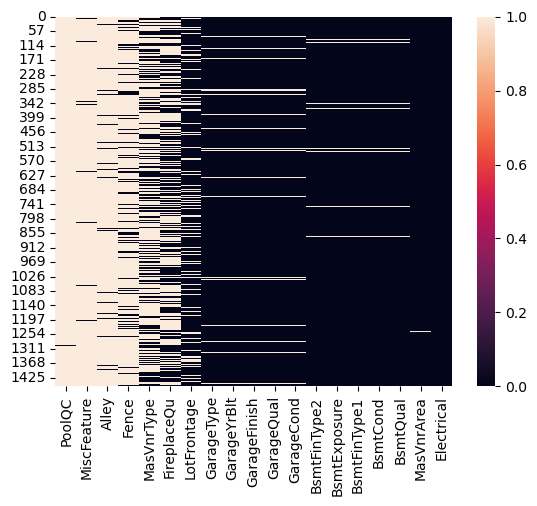

In [7]:

sns.heatmap(df[missing_cols].isnull())